In [27]:
%load_ext autoreload
%autoreload 2

import featuregraph_research as fg
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
fault_num = 1

In [29]:
eastman = fg.datasets.eastman(
    dataset="faultfree_training",
    fault_number=0,
    simulation_run=1,
)

group = ["fault_number", "simulation_run"]

eastman_oscillation = fg.oscillation.Oscillation(
    signals="reactor_pressure",
    group=group,
    smooth_signal=True,
    smooth_window=20,
)
eastman_oscillation_features = eastman_oscillation.fit_transform(eastman)
eastman_oscillation_objects = eastman_oscillation.summarize(
    eastman_oscillation_features,
    signal="reactor_pressure",
)

eastman_accumulation = fg.accumulation.Accumulation(
    signals="reactor_pressure",
    group=group,
)
eastman_accumulation_features = eastman_accumulation.fit_transform(
    eastman_oscillation_features
)
eastman_accumulation_objects = eastman_accumulation.summarize(
    eastman_accumulation_features,
    signal="reactor_pressure",
)


In [30]:
faulty_eastman = fg.datasets.eastman(
    dataset="faulty_training",
    fault_number=fault_num,
    simulation_run=1,
)

faulty_group = ["fault_number", "simulation_run"]

faulty_eastman_oscillation = fg.oscillation.Oscillation(
    signals="reactor_pressure",
    group=faulty_group,
    smooth_signal=True,
    smooth_window=20,
)
faulty_eastman_oscillation_features = faulty_eastman_oscillation.fit_transform(
    faulty_eastman
)
faulty_eastman_oscillation_objects = faulty_eastman_oscillation.summarize(
    faulty_eastman_oscillation_features,
    signal="reactor_pressure",
)

faulty_eastman_accumulation = fg.accumulation.Accumulation(
    signals="reactor_pressure",
    group=faulty_group,
)
faulty_eastman_accumulation_features = faulty_eastman_accumulation.fit_transform(
    faulty_eastman_oscillation_features
)
faulty_eastman_accumulation_objects = faulty_eastman_accumulation.summarize(
    faulty_eastman_accumulation_features,
    signal="reactor_pressure",
)

In [31]:
eastman_oscillation_features[f'reactor_pressure_fault_{fault_num}'] = faulty_eastman_oscillation_features['reactor_pressure_smooth']
eastman_oscillation_features['reactor_pressure_mean'] = eastman_oscillation_features['reactor_pressure_smooth'].mean()
eastman_oscillation_features['reactor_pressure_max'] = eastman_oscillation_features['reactor_pressure_smooth'].max()
eastman_oscillation_features['reactor_pressure_min'] = eastman_oscillation_features['reactor_pressure_smooth'].min()
eastman_oscillation_features['fault_reactor_pressure_exceeded_high_limit'] = eastman_oscillation_features[f'reactor_pressure_fault_{fault_num}'] > eastman_oscillation_features['reactor_pressure_max']
eastman_oscillation_features['fault_reactor_pressure_exceeded_low_limit'] = eastman_oscillation_features[f'reactor_pressure_fault_{fault_num}'] < eastman_oscillation_features['reactor_pressure_min']

eastman_oscillation_features[f'enter_fault_{fault_num}_episode'] = eastman_oscillation_features['fault_reactor_pressure_exceeded_high_limit'].astype(int).diff() == 1
eastman_oscillation_features[f'fault_{fault_num}_episode_id'] = eastman_oscillation_features[eastman_oscillation_features['fault_reactor_pressure_exceeded_high_limit'] == 1][f'enter_fault_{fault_num}_episode'].cumsum()
eastman_oscillation_features['index'] = eastman_oscillation_features.index

(<Figure size 1600x1100 with 5 Axes>,
 array([<Axes: ylabel='reactor_pressure_smooth\nreactor_pressure_mean\nreactor_pressure_max\nreactor_pressure_min\nreactor_pressure_fault_1'>,
        <Axes: ylabel='fault_reactor_pressure_exceeded_high_limit'>,
        <Axes: ylabel='fault_reactor_pressure_exceeded_low_limit'>,
        <Axes: ylabel='fault_1_episode_id'>,
        <Axes: xlabel='Time', ylabel='reactor_pressure_wave_id'>],
       dtype=object))

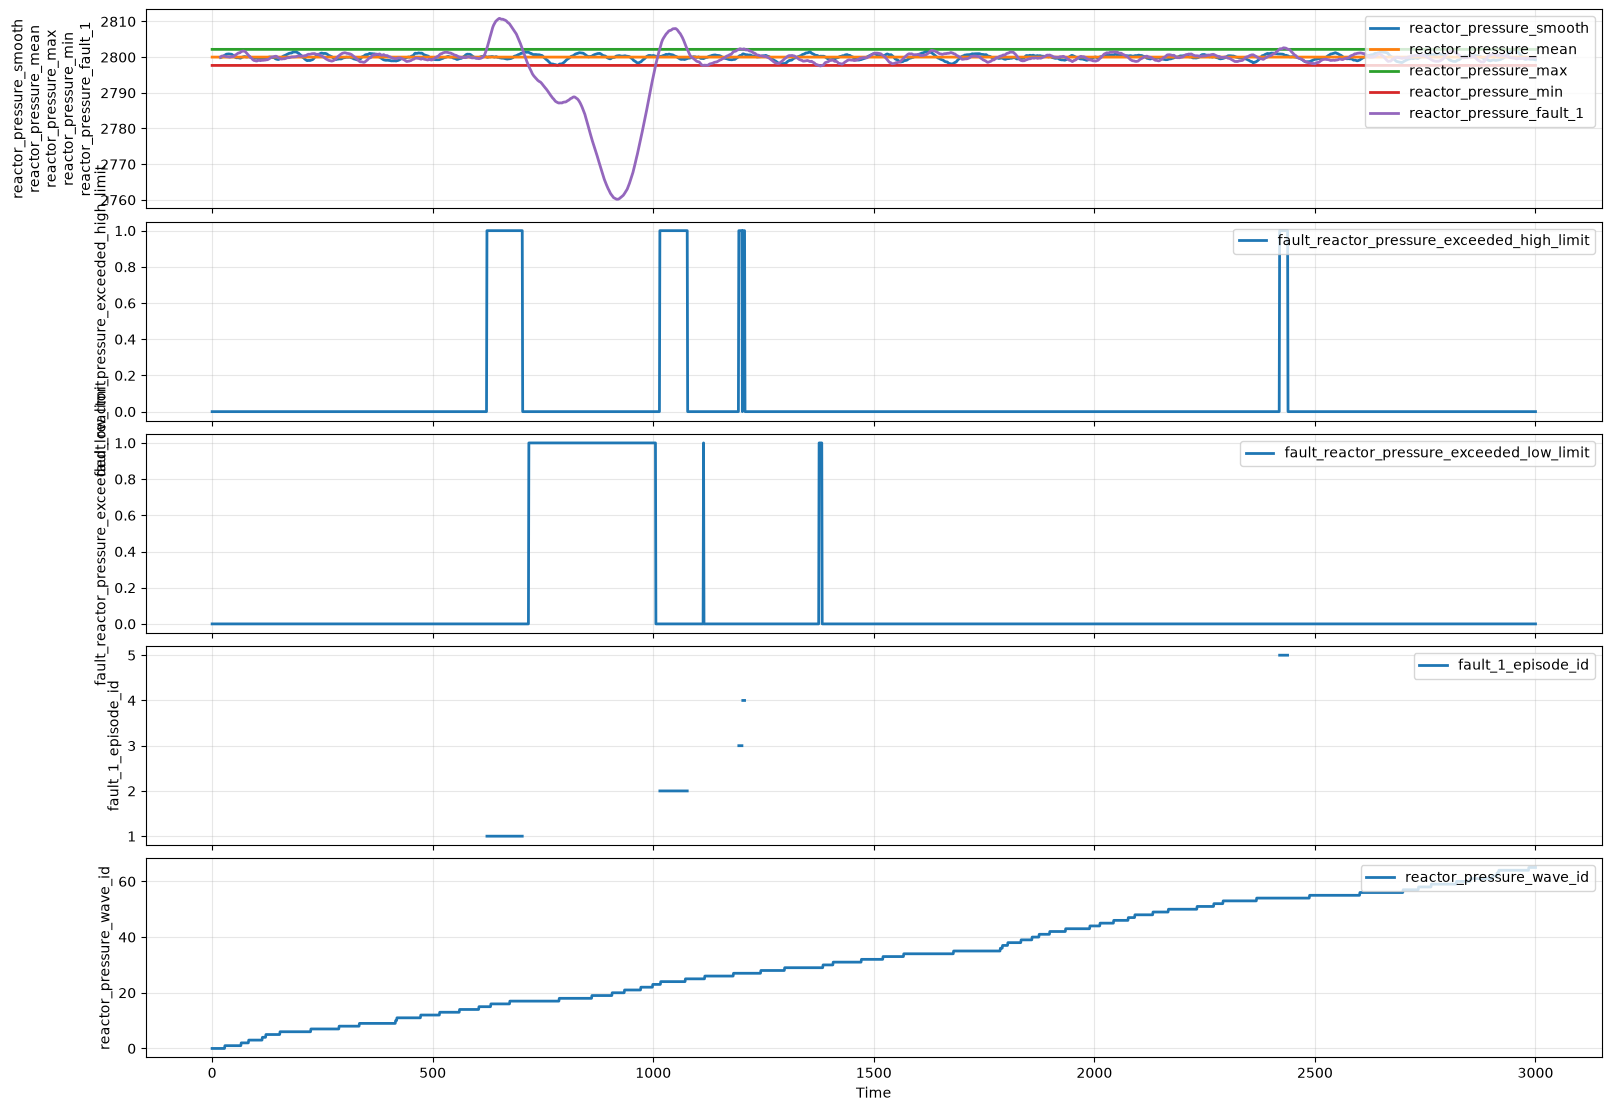

In [32]:
fg.plot(eastman_oscillation_features, [['reactor_pressure_smooth', 'reactor_pressure_mean', 'reactor_pressure_max', 'reactor_pressure_min', f'reactor_pressure_fault_{fault_num}'],
                                       ['fault_reactor_pressure_exceeded_high_limit'],
                                       ['fault_reactor_pressure_exceeded_low_limit'],
                                       [f'fault_{fault_num}_episode_id'],
                                       ['reactor_pressure_wave_id']
                                       ])

In [33]:
summarydf = eastman_oscillation_features.groupby(f'fault_{fault_num}_episode_id').agg(
    start_index=('index', 'first'),
    end_index=('index', 'last'),
    duration=('fault_reactor_pressure_exceeded_high_limit', 'sum'),
    reactor_pressure_wave_id_min=('reactor_pressure_wave_id', 'min'),
    reactor_pressure_wave_id_max=('reactor_pressure_wave_id', 'max')
)

In [34]:
episodes = (
    summarydf
    .reset_index()
    .rename(
        columns={
            "start_index": "episode_start_index",
            "end_index": "episode_end_index",
            "duration": "episode_duration",
        }
    )
)

waves = (
    faulty_eastman_oscillation_objects.table
    .rename(
        columns={
            "start_index": "wave_start_index",
            "end_index": "wave_end_index",
            "duration": "wave_duration",
        }
    )
)

In [35]:
episodes

,fault_1_episode_id,episode_start_index,episode_end_index,episode_duration,reactor_pressure_wave_id_min,reactor_pressure_wave_id_max
0,1.0,623,703,81,15,17
1,2.0,1015,1077,63,23,25
2,3.0,1194,1201,8,27,27
3,4.0,1203,1207,5,27,27
4,5.0,2420,2438,19,54,54


In [36]:
fault_1_waves = waves.loc[
    (waves["fault_number"] == 1)
    & (waves["simulation_run"] == 1)
].copy()

episode_wave_links = (
    episodes.assign(_key=1)
    .merge(fault_1_waves.assign(_key=1), on="_key")
    .drop(columns="_key")
)

episode_wave_links = episode_wave_links.loc[
    (episode_wave_links["wave_start_index"]
     <= episode_wave_links["episode_end_index"])
    &
    (episode_wave_links["wave_end_index"]
     >= episode_wave_links["episode_start_index"])
]

In [37]:
episode_wave_links[
    [
        f"fault_{fault_num}_episode_id",
        "episode_start_index",
        "episode_end_index",
        "oscillation_id",
        "wave_start_index",
        "wave_end_index",
        "amplitude",
        "period",
        "temporal_symmetry",
    ]
]

,fault_1_episode_id,episode_start_index,episode_end_index,oscillation_id,wave_start_index,wave_end_index,amplitude,period,temporal_symmetry
14,1.0,623,703,15,609.0,794.0,11.860252,72.0,0.529730
72,2.0,1015,1077,17,923.0,1122.0,23.782994,228.0,0.693467
129,3.0,1194,1201,18,1122.0,1287.0,2.319355,152.0,0.993939
185,4.0,1203,1207,18,1122.0,1287.0,2.319355,152.0,0.993939
266,5.0,2420,2438,43,2385.0,2501.0,2.234683,73.0,0.862069


In [38]:
def describe_exceedance_episodes(
    episodes,
    *,
    fault_label,
    signal_label,
    direction,
):
    if episodes.empty:
        return (
            f"No {direction}-limit exceedance episodes were identified "
            f"in the {fault_label} {signal_label} trace."
        )

    n = len(episodes)
    episode_word = "episode" if n == 1 else "episodes"
    verb = "was" if n == 1 else "were"

    sentences = [
        f"{n} {direction}-limit exceedance {episode_word} "
        f"{verb} identified in the {fault_label} {signal_label} trace."
    ]

    for _, row in episodes.iterrows():
        episode_id = int(row[f"fault_{fault_num}_episode_id"])
        start = int(row["episode_start_index"])
        end = int(row["episode_end_index"])
        duration = int(row["episode_duration"])

        wave_min = int(row["reactor_pressure_wave_id_min"])
        wave_max = int(row["reactor_pressure_wave_id_max"])

        if wave_min == wave_max:
            wave_text = f"wave {wave_min}"
        else:
            wave_text = f"waves {wave_min}–{wave_max}"

        sentences.append(
            f"Episode {episode_id} extended from samples "
            f"{start} through {end}, lasted {duration} samples, "
            f"and overlapped {wave_text}."
        )

    return " ".join(sentences)

In [39]:
message = describe_exceedance_episodes(
    episode_wave_links,
    fault_label=f"Fault {fault_num}",
    signal_label="reactor-pressure",
    direction="upper",
)

print(message)

5 upper-limit exceedance episodes were identified in the Fault 1 reactor-pressure trace. Episode 1 extended from samples 623 through 703, lasted 81 samples, and overlapped waves 15–17. Episode 2 extended from samples 1015 through 1077, lasted 63 samples, and overlapped waves 23–25. Episode 3 extended from samples 1194 through 1201, lasted 8 samples, and overlapped wave 27. Episode 4 extended from samples 1203 through 1207, lasted 5 samples, and overlapped wave 27. Episode 5 extended from samples 2420 through 2438, lasted 19 samples, and overlapped wave 54.
